# Two-Tower Uplift Model — Scooter Retention

This notebook trains and evaluates a Two-Tower MLP uplift model that estimates the individual treatment effect (ITE) of marketing gifts on scooter retention.

**Data:** A/B tests (2025), segments `active_users` and `return_users`.  
**Target:** `rides_cumulative_30_days > 0` (retained within 30 days after treatment).  
**Primary metric:** Qini AUC. Baseline: T-Learner with logistic regression.  


In [19]:
import gc
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

SEED = 99
random.seed(SEED)
np.random.seed(SEED)
import torch as _torch_init
_torch_init.manual_seed(SEED)
_torch_init.cuda.manual_seed_all(SEED)
_torch_init.backends.cudnn.deterministic = True
_torch_init.backends.cudnn.benchmark     = False

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

MAX_METRIC_ROWS   = 100_000
TRAIN_SAMPLE_FRAC = 1.0          

print('Imports loaded')


Imports loaded


## 1. Data Loading

In [21]:
# ── File paths ────────────────────────────────────────────────────────────────
# Download source files from Yandex Disk and place them next to this notebook:
#   df_combined_noisy.csv   — AB-experiment data with injected noise
#   user_features.csv       — pre-session user behavioural features
NOISY_PATH    = '/Users/maryashina-as/Documents/HSE/ВКР/data/noisy_data/df_combined_noisy.csv'
FEATURES_PATH = '/Users/maryashina-as/Documents/HSE/ВКР/data/user_features.csv'

# ── Load AB-experiment data ────────────────────────────────────────────────────
df_combined = pd.read_csv(NOISY_PATH, sep=';')

df_combined['ab_group_name'] = df_combined['ab_group_name'].astype(str).str.strip().str.lower()
test_groups = {'test_discount', 'test_minutes', 'test_unlock'}
df_combined['is_control']        = df_combined['ab_group_name'].isin({'control'}).astype(int)
df_combined['is_global_control'] = df_combined['ab_group_name'].isin({'global_control'}).astype(int)
df_combined['is_test']           = df_combined['ab_group_name'].isin(test_groups).astype(int)

agg = df_combined.groupby('phone_pd_id').agg(
    is_global_control=('is_global_control', 'max'),
    is_test=('is_test', 'max'),
    is_control=('is_control', 'max')
).reset_index()
to_exclude = set(agg[(agg.is_global_control == 1) & (agg.is_test == 1)].phone_pd_id) | \
             set(agg[(agg.is_global_control == 1) & (agg.is_control == 1)].phone_pd_id)
del agg

df_combined = df_combined[~df_combined['phone_pd_id'].isin(to_exclude)]
df_combined.drop(columns=['is_control', 'is_test', 'is_global_control', 'group_category'], errors='ignore', inplace=True)
df_combined['ab_group_name'] = df_combined['ab_group_name'].replace('global_control', 'control')
df_combined.drop(columns=['local_exp3_hash', 'yandex_uid'], errors='ignore', inplace=True)
df_combined.replace(['no_value', 'nan', 'NaN', ' ', '', 'null', 'NULL', 'None', '-'], np.nan, inplace=True)

numerical_cols = [
    'gmv_1_week', 'gmv_2_week', 'gmv_cumulative_30_days', 'gmv_cumulative_total',
    'order_duration_sec_1_week', 'order_duration_sec_2_week',
    'order_duration_sec_cumulative_30_days', 'order_duration_sec_cumulative_total',
    'package_revenue_1_week', 'package_revenue_2_week',
    'package_revenue_cumulative_30_days', 'package_revenue_cumulative_total',
    'rent_revenue_1_week', 'rent_revenue_2_week',
    'rent_revenue_cumulative_30_days', 'rent_revenue_cumulative_total',
    'rides_1_week', 'rides_2_week', 'rides_cumulative_30_days', 'rides_cumulative_total',
    'subscription_revenue_1_week', 'subscription_revenue_2_week',
    'subscription_revenue_cumulative_30_days', 'subscription_revenue_cumulative_total',
]
num_present = [c for c in numerical_cols if c in df_combined.columns]
df_combined[num_present] = df_combined[num_present].apply(pd.to_numeric, errors='coerce')

print(f'df_combined: {df_combined.shape[0]:,} rows x {df_combined.shape[1]} columns')


df_combined: 2,875,631 rows x 32 columns


In [22]:
# ── Load pre-session user behavioural features ─────────────────────────────────
df_features = pd.read_csv(FEATURES_PATH, sep=';', decimal='.', na_values=['empty', ''])
df_features.drop(columns=['user_session_id', 'country_code'], errors='ignore', inplace=True)

non_num = ['phone_pd_id', 'start_date', 'features_date', 'country_name_en', 'scooters_geo_city_name_en']
num_feat_cols = [c for c in df_features.columns if c not in non_num]
df_features[num_feat_cols] = df_features[num_feat_cols].apply(pd.to_numeric, errors='coerce')

for col in ['market_gmv', 'order_estimated_ride_distance_km_1m_avg',
            'order_estimated_ride_distance_km_1m_sum', 'order_estimated_ride_distance_km_1w_avg',
            'order_estimated_ride_distance_km_1w_sum', 'order_estimated_ride_distance_km_avg',
            'order_estimated_ride_distance_km_sum']:
    if col in df_features.columns:
        df_features[col] = df_features[col].clip(lower=0)

df_features[num_feat_cols] = df_features[num_feat_cols].fillna(0)
print(f'df_features: {df_features.shape[0]:,} rows x {df_features.shape[1]} columns')


df_features: 7,875,658 rows x 130 columns


In [23]:
# ── Create target variable ─────────────────────────────────────────────────────
# Target: user made at least one ride in the 30 days following the experiment
df_combined['target_retention'] = (df_combined['rides_cumulative_30_days'] > 0).astype(int)
print('Target distribution:')
print(df_combined['target_retention'].value_counts(normalize=True).round(3))

# Drop post-period outcome columns to prevent data leakage
post_period_cols = [
    'gmv_1_week', 'gmv_2_week', 'gmv_cumulative_30_days', 'gmv_cumulative_total',
    'rides_1_week', 'rides_2_week', 'rides_cumulative_30_days', 'rides_cumulative_total',
    'order_duration_sec_1_week', 'order_duration_sec_2_week',
    'order_duration_sec_cumulative_30_days', 'order_duration_sec_cumulative_total',
    'package_revenue_1_week', 'package_revenue_2_week',
    'package_revenue_cumulative_30_days', 'package_revenue_cumulative_total',
    'rent_revenue_1_week', 'rent_revenue_2_week',
    'rent_revenue_cumulative_30_days', 'rent_revenue_cumulative_total',
    'subscription_revenue_1_week', 'subscription_revenue_2_week',
    'subscription_revenue_cumulative_30_days', 'subscription_revenue_cumulative_total',
]
df_combined.drop(columns=[c for c in post_period_cols if c in df_combined.columns], inplace=True)

# ── Merge AB data with user features ──────────────────────────────────────────
df_model = pd.merge(df_combined, df_features, on='phone_pd_id', how='inner')
del df_combined, df_features; gc.collect()

df_model['gift_name']    = df_model['gift_name'].fillna('no_gift')
df_model['is_treatment'] = (df_model['ab_group_name'] != 'control').astype(int)
df_model = df_model.copy()

print(f'\ndf_model: {df_model.shape[0]:,} rows x {df_model.shape[1]} columns')


Target distribution:
target_retention
0   0.8380
1   0.1620
Name: proportion, dtype: float64

df_model: 1,898,116 rows x 139 columns


## 2. Feature Preparation

In [24]:
id_cols = [
    'phone_pd_id', 'ab_group_name', 'gift_name', 'segment_name', 'test_name',
    'utc_segment_dt', 'segment_end_dt', 'start_date', 'features_date',
    'country_code', 'country_name_en', 'scooters_geo_city_name_en',
    'is_treatment', 'target_retention'
]
user_features_cols      = [c for c in df_model.columns if c not in id_cols]
treatment_features_cols = ['gift_name', 'utc_segment_dt', 'segment_end_dt']
date_cols               = ['utc_segment_dt', 'segment_end_dt']
treatment_cat_cols      = ['gift_name']
user_cat_cols           = ['segment_name']

df_user      = df_model[user_features_cols + ['segment_name']].copy()
df_treatment = df_model[treatment_features_cols].copy()
df_treatment['offer_duration_days'] = (
    pd.to_datetime(df_model['segment_end_dt'], errors='coerce') -
    pd.to_datetime(df_model['utc_segment_dt'], errors='coerce')
).dt.days.fillna(0).astype(float)

y = df_model['target_retention'].copy()
t = df_model['is_treatment'].copy()

print(f"User features: {df_user.shape[1]} | Treatment features: {df_treatment.shape[1]}")


def process_dates(df, cols):
    """Decompose datetime columns into day-of-week, month and day."""
    df = df.copy()
    for col in cols:
        if col in df.columns:
            dt = pd.to_datetime(df[col], errors='coerce')
            df[f'{col}_dayofweek'] = dt.dt.dayofweek.fillna(0).astype(int)
            df[f'{col}_month']     = dt.dt.month.fillna(0).astype(int)
            df[f'{col}_day']       = dt.dt.day.fillna(0).astype(int)
            df.drop(columns=[col], inplace=True)
    return df


def encode_df(df, encoder, cat_cols):
    """Apply a pre-fitted OneHotEncoder to selected columns."""
    df    = df.copy()
    enc   = encoder.transform(df[cat_cols])
    enc_df = pd.DataFrame(enc, columns=encoder.get_feature_names_out(cat_cols), index=df.index)
    return pd.concat([df.drop(columns=cat_cols), enc_df], axis=1)


def compute_iptw(X_scaled, t_series, ps_model, clip_low=5, clip_high=95, eps=1e-6):
    """Inverse Probability of Treatment Weighting with symmetric percentile clipping."""
    prop = ps_model.predict_proba(X_scaled)[:, 1]
    w    = np.where(np.asarray(t_series) == 1, 1 / (prop + eps), 1 / (1 - prop + eps))
    return np.clip(w, np.percentile(w, clip_low), np.percentile(w, clip_high))


def subsample_for_metrics(y, uplift, treatment, n=MAX_METRIC_ROWS, seed=42):
    if len(y) <= n:
        return y, uplift, treatment
    idx = np.random.default_rng(seed).choice(len(y), size=n, replace=False)
    return y[idx], uplift[idx], treatment[idx]


print('Helper functions defined')


User features: 126 | Treatment features: 4
Helper functions defined


## 3. Train / Val / Test Split

In [25]:
stratify_col = df_model['segment_name'].astype(str) + '_' + df_model['is_treatment'].astype(str)

X_train, X_temp, y_train, y_temp, u_train, u_temp, t_train, t_temp = train_test_split(
    df_user, y, df_treatment, t, test_size=0.3, random_state=42, stratify=stratify_col
)
X_val, X_test, y_val, y_test, u_val, u_test, t_val, t_test = train_test_split(
    X_temp, y_temp, u_temp, t_temp, test_size=0.5, random_state=42,
    stratify=stratify_col[X_temp.index]
)
del X_temp, y_temp, u_temp, t_temp
gc.collect()
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

# One-hot encode user categorical features
user_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
user_encoder.fit(X_train[user_cat_cols])
X_train = encode_df(X_train, user_encoder, user_cat_cols).fillna(0)
X_val   = encode_df(X_val,   user_encoder, user_cat_cols).fillna(0)
X_test  = encode_df(X_test,  user_encoder, user_cat_cols).fillna(0)

# Keep raw treatment DataFrames for counterfactual vector construction
u_train_raw = u_train.copy()
u_val_raw   = u_val.copy()
u_test_raw  = u_test.copy()

# One-hot encode treatment features
treatment_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
treatment_encoder.fit(u_train_raw[treatment_cat_cols])
u_train = encode_df(process_dates(u_train, date_cols), treatment_encoder, treatment_cat_cols).fillna(0)
u_val   = encode_df(process_dates(u_val,   date_cols), treatment_encoder, treatment_cat_cols).fillna(0)
u_test  = encode_df(process_dates(u_test,  date_cols), treatment_encoder, treatment_cat_cols).fillna(0)

# Standardise
scaler_user  = StandardScaler()
scaler_treat = StandardScaler()
X_train_scaled = scaler_user.fit_transform(X_train)
X_val_scaled   = scaler_user.transform(X_val)
X_test_scaled  = scaler_user.transform(X_test)
u_train_scaled = scaler_treat.fit_transform(u_train)
u_val_scaled   = scaler_treat.transform(u_val)
u_test_scaled  = scaler_treat.transform(u_test)

# Propensity model + IPTW weights
ps_model = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
ps_model.fit(X_train_scaled, t_train)
weights_train = compute_iptw(X_train_scaled, t_train, ps_model)
weights_val   = compute_iptw(X_val_scaled,   t_val,   ps_model)
weights_test  = compute_iptw(X_test_scaled,  t_test,  ps_model)

# Random subsample of training data (TRAIN_SAMPLE_FRAC < 1.0 reduces size)
n_train_use  = int(len(X_train_scaled) * TRAIN_SAMPLE_FRAC)
_rng_train   = np.random.default_rng(42)
_train_idx   = _rng_train.choice(len(X_train_scaled), size=n_train_use, replace=False)

X_tr_use     = X_train_scaled[_train_idx]
u_tr_use     = u_train_scaled[_train_idx]
y_tr_use     = y_train.iloc[_train_idx]
t_tr_use     = t_train.iloc[_train_idx]
w_tr_use     = weights_train[_train_idx]
u_tr_raw_use = u_train_raw.iloc[_train_idx]

print(f"Training set size: {n_train_use:,} rows")
print('Preprocessing complete')


Train: 1,328,681 | Val: 284,717 | Test: 284,718
Training set size: 1,328,681 rows
Preprocessing complete


## 4. Two-Tower Model Architecture

The model contains two independent MLP towers: **user_tower** processes user features, **treat_tower** processes treatment features (gift type and dates). Their embeddings are concatenated and passed to a shared prediction head.

Uplift is computed as: `uplift = σ(logit_treat) − σ(logit_ctrl)`, where `ctrl_vec` is the `no_gift` vector for every user.

**Loss function:** BCE with IPTW weights — treated users are trained on `logit_treat`, control users on `logit_ctrl`.  
**Dropout = 0.2:** noisy data acts as implicit regularisation, so a low dropout value is sufficient.


In [26]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')


def to_tensor(arr, dtype=torch.float32):
    return torch.tensor(np.asarray(arr), dtype=dtype).to(device)


def uplift_aware_loss(logits_treat, logits_ctrl, y_true, treatment, weight):
    """BCE with IPTW weights: treated users learn from logit_treat, control from logit_ctrl."""
    bce           = nn.BCEWithLogitsLoss(reduction='none')
    treat_mask    = treatment.float()
    logits_actual = logits_treat * treat_mask + logits_ctrl * (1 - treat_mask)
    loss          = bce(logits_actual, y_true)
    w_norm        = weight / (weight.mean() + 1e-8)
    return (loss * w_norm).mean()


class TwoTowerModel(nn.Module):
    """
    Two independent MLP towers for user and treatment embeddings.
    Embeddings are concatenated and passed to a shared prediction head.
    dropout=0.2: noisy data provides implicit regularisation.
    """
    def __init__(self, user_dim, treat_dim, embed_dim=64, hidden_dims=[256, 128, 64], dropout=0.2):
        super().__init__()

        def make_tower(in_dim):
            layers, prev = [], in_dim
            for h in hidden_dims:
                layers += [nn.Linear(prev, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
                prev = h
            layers.append(nn.Linear(prev, embed_dim))
            return nn.Sequential(*layers)

        self.user_tower  = make_tower(user_dim)
        self.treat_tower = make_tower(treat_dim)
        self.head = nn.Sequential(
            nn.BatchNorm1d(embed_dim * 2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(embed_dim * 2, 32), nn.ReLU(), nn.Linear(32, 1)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, user, treat):
        return self.head(torch.cat([self.user_tower(user), self.treat_tower(treat)], dim=1))

    def forward_both(self, user, treat_vec, ctrl_vec):
        """Single user_tower pass shared between treat and ctrl — saves compute."""
        u_emb = self.user_tower(user)
        lt = self.head(torch.cat([u_emb, self.treat_tower(treat_vec)], dim=1))
        lc = self.head(torch.cat([u_emb, self.treat_tower(ctrl_vec)],  dim=1))
        return lt, lc


def _encode_treatment(u_raw_df, treat_encoder, scaler):
    u = encode_df(process_dates(u_raw_df.copy(), date_cols),
                  treat_encoder, treatment_cat_cols).fillna(0)
    return scaler.transform(u)


def build_counterfactual_arrays_per_user(u_raw_df, t_series, treat_encoder, scaler):
    """
    Build per-user counterfactual treatment vectors:
      treat_vec — the user's actual gift (or no_gift for control)
      ctrl_vec  — no_gift for every user
    This lets the model learn from real outcomes in both groups.
    """
    treat_sc = _encode_treatment(u_raw_df, treat_encoder, scaler)
    u_ctrl   = u_raw_df.copy()
    u_ctrl['gift_name'] = 'no_gift'
    ctrl_sc  = _encode_treatment(u_ctrl, treat_encoder, scaler)
    t_arr    = np.asarray(t_series).reshape(-1, 1)
    actual   = np.where(t_arr == 1, treat_sc, ctrl_sc)
    counter  = np.where(t_arr == 1, ctrl_sc,  treat_sc)
    return actual, counter, treat_sc, ctrl_sc


def train_two_tower(X_tr_sc, u_actual_tr, u_counter_tr,
                    y_tr, t_tr, w_tr,
                    X_va_sc, u_actual_va, u_counter_va,
                    y_va, t_va, w_va,
                    epochs=30, batch_size=4096, patience=6,
                    fold_id=0, seed=42):
    torch.manual_seed(seed)
    model     = TwoTowerModel(X_tr_sc.shape[1], u_actual_tr.shape[1]).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

    _g = torch.Generator()
    _g.manual_seed(seed)
    loader = DataLoader(
        TensorDataset(
            to_tensor(X_tr_sc), to_tensor(u_actual_tr), to_tensor(u_counter_tr),
            to_tensor(np.asarray(y_tr).reshape(-1, 1)),
            to_tensor(np.asarray(t_tr).reshape(-1, 1)),
            to_tensor(w_tr.reshape(-1, 1))
        ),
        batch_size=batch_size, shuffle=True, drop_last=False, generator=_g
    )

    val_X  = to_tensor(X_va_sc);       val_ua = to_tensor(u_actual_va)
    val_uc = to_tensor(u_counter_va);  val_y  = to_tensor(np.asarray(y_va).reshape(-1, 1))
    val_t  = to_tensor(np.asarray(t_va).reshape(-1, 1))
    val_w  = to_tensor(np.asarray(w_va).reshape(-1, 1))

    best_loss, counter_es, path = float('inf'), 0, f'best_tt_{fold_id}.pth'
    for epoch in range(epochs):
        model.train()
        for Xb, ua_b, uc_b, yb, tb, wb in loader:
            optimizer.zero_grad()
            lt, lc = model.forward_both(Xb, ua_b, uc_b)
            loss   = uplift_aware_loss(lt, lc, yb, tb, wb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        with torch.no_grad():
            lt_v, lc_v = model.forward_both(val_X, val_ua, val_uc)
            val_loss   = uplift_aware_loss(lt_v, lc_v, val_y, val_t, val_w).item()
        scheduler.step(val_loss)

        if (epoch + 1) % 5 == 0:
            print(f'  Epoch {epoch+1}: val_loss={val_loss:.4f} | lr={optimizer.param_groups[0]["lr"]:.1e}')

        if val_loss < best_loss:
            best_loss = val_loss;  counter_es = 0
            torch.save(model.state_dict(), path)
        else:
            counter_es += 1
            if counter_es >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(torch.load(path, weights_only=True))
    model.eval()
    if os.path.exists(path):
        os.remove(path)
    return model


def predict_uplift_per_user(model, X_sc, u_raw_df, treat_encoder, scaler,
                            default_gift=None):
    """
    uplift = P(retention | gift) - P(retention | no_gift).
    For control users, the most frequent gift type from the treated group is used
    as the hypothetical treatment vector.
    """
    if default_gift is None:
        treat_gifts  = u_raw_df[u_raw_df['gift_name'] != 'no_gift']['gift_name']
        default_gift = treat_gifts.mode()[0] if len(treat_gifts) > 0 else 'no_gift'
    u_treat = u_raw_df.copy()
    u_treat.loc[u_treat['gift_name'] == 'no_gift', 'gift_name'] = default_gift
    treat_sc = _encode_treatment(u_treat, treat_encoder, scaler)
    u_ctrl   = u_raw_df.copy()
    u_ctrl['gift_name'] = 'no_gift'
    ctrl_sc  = _encode_treatment(u_ctrl, treat_encoder, scaler)
    with torch.no_grad():
        p_t = torch.sigmoid(model(to_tensor(X_sc), to_tensor(treat_sc))).cpu().numpy().flatten()
        p_c = torch.sigmoid(model(to_tensor(X_sc), to_tensor(ctrl_sc))).cpu().numpy().flatten()
    return p_t - p_c


def predict_uplift_by_gift(model, X_sc, u_raw_df, treat_encoder, scaler):
    """Compute per-gift uplift vs no_gift — key advantage of the Two-Tower design."""
    gifts    = [g for g in u_raw_df['gift_name'].unique() if g != 'no_gift']
    u_ctrl   = u_raw_df.copy()
    u_ctrl['gift_name'] = 'no_gift'
    ctrl_sc  = _encode_treatment(u_ctrl, treat_encoder, scaler)
    with torch.no_grad():
        p_c = torch.sigmoid(model(to_tensor(X_sc), to_tensor(ctrl_sc))).cpu().numpy().flatten()
    results = {'no_gift_baseline': p_c}
    for gift in sorted(gifts):
        u_g  = u_raw_df.copy()
        u_g['gift_name'] = gift
        treat_sc = _encode_treatment(u_g, treat_encoder, scaler)
        with torch.no_grad():
            p_t = torch.sigmoid(model(to_tensor(X_sc), to_tensor(treat_sc))).cpu().numpy().flatten()
        results[gift] = p_t - p_c
    return results


print('Architecture defined')


Device: cpu
Architecture defined


## 5. Metric Functions

In [27]:
try:
    from sklift.metrics import qini_auc_score, uplift_auc_score
    SKLIFT_OK = True
    print('scikit-uplift imported')
except Exception:
    SKLIFT_OK = False
    print('scikit-uplift not available — using manual implementations')


def _sort_df(y, uplift, treatment):
    return (pd.DataFrame({'y': y, 't': treatment, 'uplift': uplift})
            .sort_values('uplift', ascending=False)
            .reset_index(drop=True))


def qini_curve(y, uplift, treatment):
    df = _sort_df(y, uplift, treatment)
    ct = (df['y'] * (df['t'] == 1)).cumsum().values
    cc = (df['y'] * (df['t'] == 0)).cumsum().values
    nt = (df['t'] == 1).cumsum().values
    nc = np.maximum((df['t'] == 0).cumsum().values, 1)
    return ct - cc * (nt / nc)


def uplift_curve(y, uplift, treatment):
    df = _sort_df(y, uplift, treatment)
    ct = (df['y'] * (df['t'] == 1)).cumsum().values
    cc = (df['y'] * (df['t'] == 0)).cumsum().values
    nt = np.maximum((df['t'] == 1).cumsum().values, 1)
    nc = np.maximum((df['t'] == 0).cumsum().values, 1)
    return (ct / nt - cc / nc) * np.arange(1, len(df) + 1)


def random_qini(y, treatment):
    nt = (treatment == 1).sum()
    nc = max((treatment == 0).sum(), 1)
    return np.linspace(0, y[treatment == 1].sum() - y[treatment == 0].sum() * (nt / nc), len(y))


def random_uplift(y, treatment):
    return np.linspace(0, (y[treatment == 1].mean() - y[treatment == 0].mean()) * len(y), len(y))


def get_qini_auc(y, uplift, treatment):
    if SKLIFT_OK:
        return float(qini_auc_score(y, uplift, treatment))
    q = qini_curve(y, uplift, treatment)
    return float(np.trapz(q - random_qini(y, treatment))) / len(y)


def get_uplift_auc(y, uplift, treatment):
    if SKLIFT_OK:
        return float(uplift_auc_score(y, uplift, treatment))
    u = uplift_curve(y, uplift, treatment)
    return float(np.trapz(u - random_uplift(y, treatment))) / len(y)


def uplift_at_k(y, uplift, treatment, k=0.3):
    df   = _sort_df(y, uplift, treatment)
    top  = df.iloc[:int(len(df) * k)]
    rr_t = top.loc[top.t == 1, 'y'].mean() if (top.t == 1).any() else 0.0
    rr_c = top.loc[top.t == 0, 'y'].mean() if (top.t == 0).any() else 0.0
    return rr_t - rr_c


def uplift_by_percentile(y, uplift, treatment, bins=10):
    df    = _sort_df(y, uplift, treatment)
    ranks = pd.Series(uplift).rank(method='first')
    df['bin'] = pd.qcut(ranks, q=bins, labels=False)
    rows = []
    for b in range(bins):
        g    = df[df['bin'] == b]
        rr_t = g.loc[g.t == 1, 'y'].mean() if (g.t == 1).any() else np.nan
        rr_c = g.loc[g.t == 0, 'y'].mean() if (g.t == 0).any() else np.nan
        upl  = (rr_t - rr_c) if not (np.isnan(rr_t) or np.isnan(rr_c)) else np.nan
        rows.append({
            'percentile':              b + 1,
            'n_treatment':             (g.t == 1).sum(),
            'n_control':               (g.t == 0).sum(),
            'response_rate_treatment': round(rr_t, 4) if not np.isnan(rr_t) else np.nan,
            'response_rate_control':   round(rr_c, 4) if not np.isnan(rr_c) else np.nan,
            'uplift':                  round(upl, 4)  if not np.isnan(upl)  else np.nan,
        })
    return pd.DataFrame(rows)


print('Metric functions defined')


scikit-uplift imported
Metric functions defined


## 6. Visualisation Functions

In [28]:
def plot_qini(y, uplift, treatment, label='Model', ax=None, color='steelblue'):
    ys, us, ts = subsample_for_metrics(y, uplift, treatment)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    n   = len(ys)
    auc = get_qini_auc(ys, us, ts)
    q   = qini_curve(ys, us, ts)
    rnd = random_qini(ys, ts)

    tick_pcts = np.array([0, 20, 40, 60, 80, 100])
    tick_idx  = (tick_pcts / 100 * n).astype(int).clip(0, n - 1)

    ax.plot(tick_pcts, q[tick_idx],   color=color, lw=2, marker='o', markersize=5,
            label=f'{label} (Qini AUC={auc:.4f})')
    ax.plot(tick_pcts, rnd[tick_idx], 'k--',        lw=1.5, marker='o', markersize=4,
            label='Random')

    ax.set_xlabel('Proportion of population targeted (%)')
    ax.set_ylabel('Qini gains')
    ax.set_xticks(tick_pcts)
    ax.legend()
    ax.grid(alpha=0.3)
    return auc


def plot_uplift_c(y, uplift, treatment, label='Model', ax=None, color='steelblue'):
    ys, us, ts = subsample_for_metrics(y, uplift, treatment)
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))
    n   = len(ys)
    auc = get_uplift_auc(ys, us, ts)
    uc  = uplift_curve(ys, us, ts)
    rnd = random_uplift(ys, ts)

    tick_pcts = np.array([0, 20, 40, 60, 80, 100])
    tick_idx  = (tick_pcts / 100 * n).astype(int).clip(0, n - 1)

    ax.plot(tick_pcts, uc[tick_idx],  color=color, lw=2, marker='o', markersize=5,
            label=f'{label} (Uplift AUC={auc:.4f})')
    ax.plot(tick_pcts, rnd[tick_idx], 'k--',        lw=1.5, marker='o', markersize=4,
            label='Random')

    ax.set_xlabel('Proportion of population targeted (%)')
    ax.set_ylabel('Cumulative uplift')
    ax.set_xticks(tick_pcts)
    ax.legend()
    ax.grid(alpha=0.3)
    return auc


print('Visualisation functions defined')


Visualisation functions defined


## 7. Model Training

In [29]:
print('Building counterfactual treatment vectors...')
u_actual_tr, u_counter_tr, _, _ = build_counterfactual_arrays_per_user(
    u_tr_raw_use, t_tr_use, treatment_encoder, scaler_treat
)
u_actual_va, u_counter_va, _, _ = build_counterfactual_arrays_per_user(
    u_val_raw, t_val, treatment_encoder, scaler_treat
)

MODEL_WEIGHTS_PATH = 'two_tower_final.pth'

if os.path.exists(MODEL_WEIGHTS_PATH):
    # Load pre-trained weights — guarantees identical results without retraining
    print(f'Loading pre-trained weights from {MODEL_WEIGHTS_PATH}...')
    final_model = TwoTowerModel(X_tr_use.shape[1], u_actual_tr.shape[1]).to(device)
    final_model.load_state_dict(torch.load(MODEL_WEIGHTS_PATH, weights_only=True))
    final_model.eval()
else:
    print(f'Training Two-Tower model (seed={SEED})...')
    final_model = train_two_tower(
        X_tr_use, u_actual_tr, u_counter_tr,
        y_tr_use, t_tr_use, w_tr_use,
        X_val_scaled, u_actual_va, u_counter_va,
        y_val, t_val, weights_val,
        epochs=60, batch_size=4096, patience=10,
        fold_id='final', seed=SEED
    )
    torch.save(final_model.state_dict(), MODEL_WEIGHTS_PATH)
    print(f'Weights saved to {MODEL_WEIGHTS_PATH}')

del u_actual_tr, u_counter_tr, u_actual_va, u_counter_va
gc.collect()

# Uplift predictions on the test set
uplift_tt = predict_uplift_per_user(
    final_model, X_test_scaled, u_test_raw, treatment_encoder, scaler_treat
)

# Per-gift uplift — key output of the Two-Tower architecture
uplift_by_gift = predict_uplift_by_gift(
    final_model, X_test_scaled, u_test_raw, treatment_encoder, scaler_treat
)
gift_names = [k for k in uplift_by_gift if k != 'no_gift_baseline']

print('\nUplift by gift type (test set mean):')
for gift, arr in uplift_by_gift.items():
    if gift != 'no_gift_baseline':
        print(f'  {gift}: mean={arr.mean():.4f} | std={arr.std():.4f}')

# Optimal gift assignment per user
gift_matrix   = np.stack([uplift_by_gift[g] for g in gift_names], axis=1)
best_gift_idx = gift_matrix.argmax(axis=1)
best_gift_arr = np.array(gift_names)[best_gift_idx]

print('\nRecommended gift distribution (test set):')
unique, counts = np.unique(best_gift_arr, return_counts=True)
for g, c in sorted(zip(unique, counts), key=lambda x: -x[1]):
    print(f'  {g}: {c:,} ({c / len(best_gift_arr):.1%})')

print(f'\nUplift: mean={uplift_tt.mean():.4f} | std={uplift_tt.std():.4f}')
print(f'Share of users with positive uplift: {(uplift_tt > 0).mean():.1%}')


Building counterfactual treatment vectors...
Loading pre-trained weights from two_tower_final_seed99.pth...

Uplift by gift type (test set mean):
  10-min-one-week: mean=0.0034 | std=0.0124
  discount-15-one-week: mean=0.0031 | std=0.0119
  free-unlock-week: mean=0.0046 | std=0.0121

Recommended gift distribution (test set):
  free-unlock-week: 259,859 (91.3%)
  discount-15-one-week: 23,956 (8.4%)
  10-min-one-week: 903 (0.3%)

Uplift: mean=0.0036 | std=0.0122
Share of users with positive uplift: 84.4%


## 8. Baseline: T-Learner (Logistic Regression)

In [30]:
print('Training T-Learner baseline (logistic regression)...')
mask_t = t_tr_use.values == 1
mask_c = t_tr_use.values == 0

lr_treat = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
lr_ctrl  = LogisticRegression(C=1.0, max_iter=1000, random_state=42, n_jobs=-1)
lr_treat.fit(X_tr_use[mask_t], y_tr_use.values[mask_t])
lr_ctrl.fit( X_tr_use[mask_c], y_tr_use.values[mask_c])

uplift_lr     = lr_treat.predict_proba(X_test_scaled)[:, 1] - lr_ctrl.predict_proba(X_test_scaled)[:, 1]
uplift_random = np.random.uniform(-0.005, 0.005, size=len(y_test))

print(f'Uplift LR: mean={uplift_lr.mean():.4f} | std={uplift_lr.std():.4f}')


Training T-Learner baseline (logistic regression)...
Uplift LR: mean=0.0063 | std=0.0127


## 9. Evaluation Metrics

In [31]:
y_test_arr = y_test.values
t_test_arr = t_test.values

n_m   = min(MAX_METRIC_ROWS, len(y_test_arr))
idx_m = np.random.default_rng(42).choice(len(y_test_arr), size=n_m, replace=False)
ys = y_test_arr[idx_m];  ts = t_test_arr[idx_m]
us_tt  = uplift_tt[idx_m]
us_lr  = uplift_lr[idx_m]
us_rnd = uplift_random[idx_m]

qini_tt     = get_qini_auc(ys, us_tt,  ts)
qini_lr     = get_qini_auc(ys, us_lr,  ts)
qini_random = get_qini_auc(ys, us_rnd, ts)
uauc_tt     = get_uplift_auc(ys, us_tt,  ts)
uauc_lr     = get_uplift_auc(ys, us_lr,  ts)
uk10_tt     = uplift_at_k(ys, us_tt, ts, k=0.1)
uk10_lr     = uplift_at_k(ys, us_lr, ts, k=0.1)
uk30_tt     = uplift_at_k(ys, us_tt, ts, k=0.3)
uk30_lr     = uplift_at_k(ys, us_lr, ts, k=0.3)

print(f"{'Metric':<25} {'Two-Tower':>12} {'Uplift LR':>12} {'Random':>10}")
print('-' * 62)
print(f"{'Qini AUC':<25} {qini_tt:>12.4f} {qini_lr:>12.4f} {qini_random:>10.4f}")
print(f"{'Uplift AUC':<25} {uauc_tt:>12.4f} {uauc_lr:>12.4f} {'—':>10}")
print(f"{'uplift@10%':<25} {uk10_tt:>12.4f} {uk10_lr:>12.4f} {'—':>10}")
print(f"{'uplift@30%':<25} {uk30_tt:>12.4f} {uk30_lr:>12.4f} {'—':>10}")

print('\n--- Per-gift Qini AUC (Two-Tower) ---')
for gift in gift_names:
    us_g = uplift_by_gift[gift][idx_m]
    q_g  = get_qini_auc(ys, us_g, ts)
    print(f'  {gift:<35} Qini AUC={q_g:.4f}')


Metric                       Two-Tower    Uplift LR     Random
--------------------------------------------------------------
Qini AUC                        0.0187       0.0032    -0.0035
Uplift AUC                      0.0129       0.0023          —
uplift@10%                      0.0241       0.0128          —
uplift@30%                      0.0152       0.0061          —

--- Per-gift Qini AUC (Two-Tower) ---
  10-min-one-week                     Qini AUC=0.0051
  discount-15-one-week                Qini AUC=0.0056
  free-unlock-week                    Qini AUC=0.0045


## 10. Qini Curves

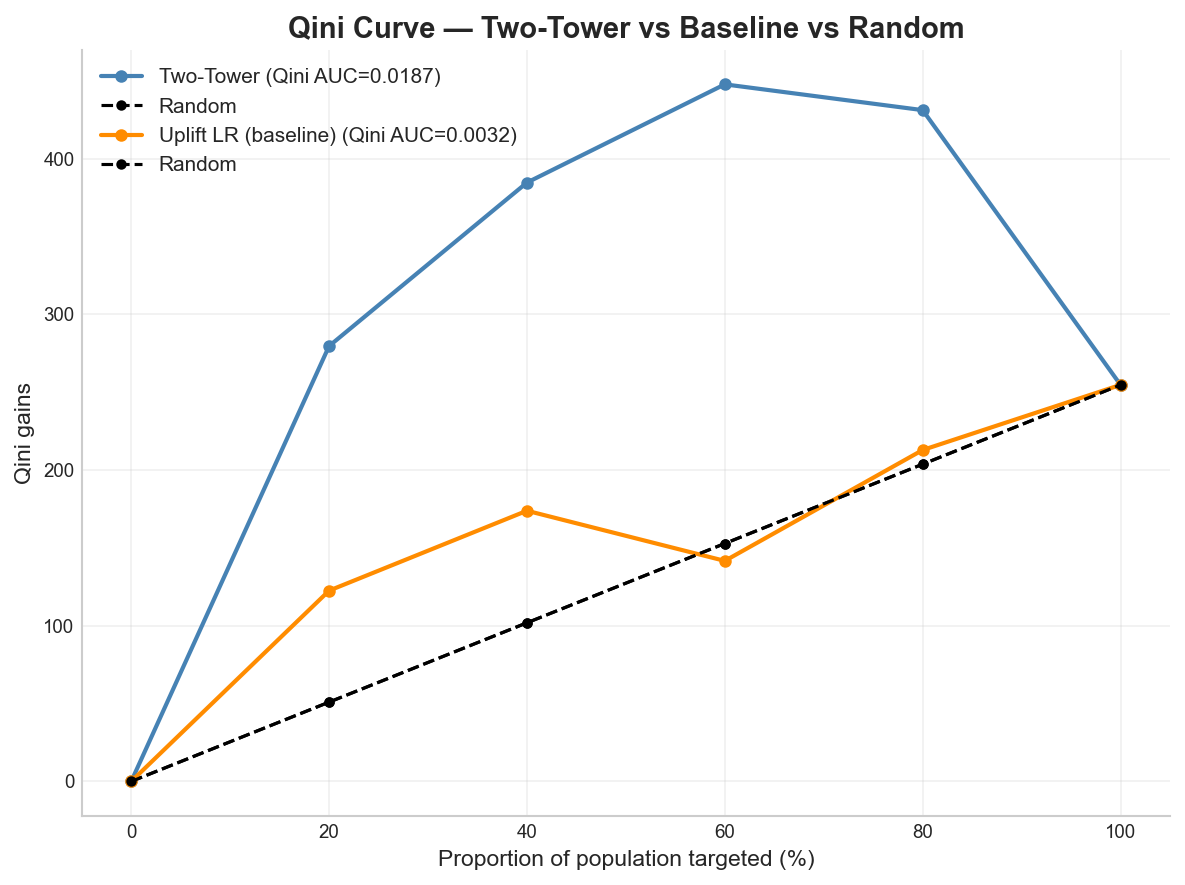

In [32]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_qini(y_test_arr, uplift_tt, t_test_arr, label='Two-Tower', ax=ax, color='steelblue')
plot_qini(y_test_arr, uplift_lr, t_test_arr, label='Uplift LR (baseline)', ax=ax, color='darkorange')
ax.set_title('Qini Curve — Two-Tower vs Baseline vs Random')
plt.tight_layout()
plt.show()


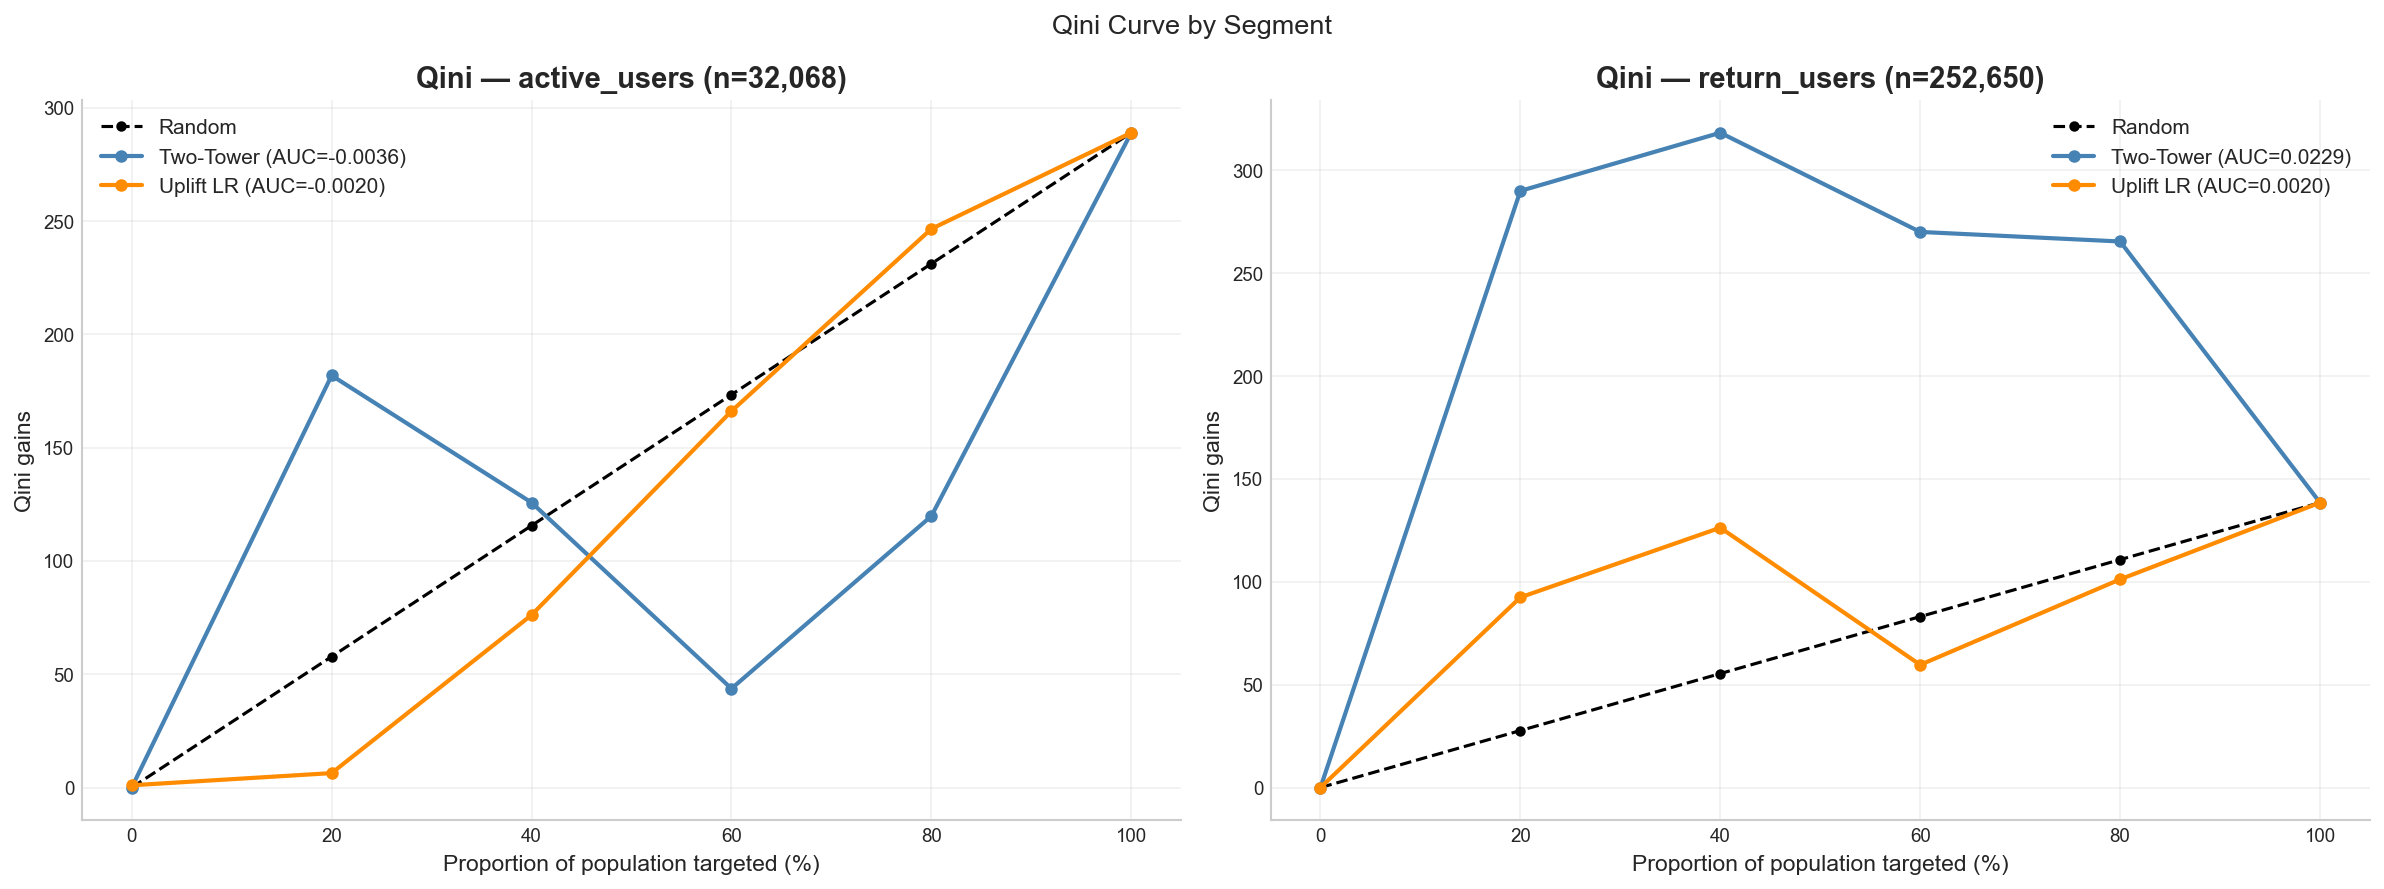


Qini AUC by segment:
  Two-Tower / active_users: -0.0036
  Two-Tower / return_users: 0.0229
  Uplift LR / active_users: -0.0020
  Uplift LR / return_users: 0.0020


In [33]:
seg_test = df_model.loc[X_test.index, 'segment_name'].values
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
segment_qini = {}

for ax, segment in zip(axes, ['active_users', 'return_users']):
    mask = seg_test == segment
    if mask.sum() == 0:
        ax.set_title(f'{segment} — no data')
        continue

    y_s = y_test_arr[mask];  t_s = t_test_arr[mask]
    n_s   = min(MAX_METRIC_ROWS, len(y_s))
    idx_s = (np.random.default_rng(42).choice(len(y_s), size=n_s, replace=False)
             if len(y_s) > n_s else np.arange(len(y_s)))
    ys_s = y_s[idx_s];  ts_s = t_s[idx_s]

    rnd_s     = random_qini(ys_s, ts_s)
    tick_pcts = np.array([0, 20, 40, 60, 80, 100])
    tick_idx  = (tick_pcts / 100 * n_s).astype(int).clip(0, n_s - 1)
    ax.plot(tick_pcts, rnd_s[tick_idx], 'k--', lw=1.5, marker='o', markersize=4, label='Random')

    for (name, upl_full), color in zip(
        [('Two-Tower', uplift_tt[mask]), ('Uplift LR', uplift_lr[mask])],
        ['steelblue', 'darkorange']
    ):
        us_s   = upl_full[idx_s]
        auc    = get_qini_auc(ys_s, us_s, ts_s)
        q_full = qini_curve(ys_s, us_s, ts_s)
        ax.plot(tick_pcts, q_full[tick_idx], color=color, lw=2, marker='o', markersize=5,
                label=f'{name} (AUC={auc:.4f})')
        segment_qini.setdefault(name, {})[segment] = auc

    ax.set_title(f'Qini — {segment} (n={mask.sum():,})')
    ax.set_xlabel('Proportion of population targeted (%)')
    ax.set_ylabel('Qini gains')
    ax.set_xticks(tick_pcts)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('Qini Curve by Segment', fontsize=13)
plt.tight_layout()
plt.show()

print('\nQini AUC by segment:')
for name, segs in segment_qini.items():
    for seg, auc in segs.items():
        print(f'  {name} / {seg}: {auc:.4f}')


## 11. Average Treatment Effect by Gift Type

In [34]:
ate_real = y_test_arr[t_test_arr == 1].mean() - y_test_arr[t_test_arr == 0].mean()
print(f'Overall ATE: {ate_real:.4f}')

print('\nATE by treatment type:')
for group in ['test_discount', 'test_minutes', 'test_unlock']:
    mask_t = df_model.loc[X_test.index, 'ab_group_name'] == group
    if mask_t.sum() > 0:
        rr_t = y_test_arr[mask_t.values].mean()
        rr_c = y_test_arr[t_test_arr == 0].mean()
        print(f'  {group}: ATE={rr_t - rr_c:+.4f} | n={mask_t.sum():,}')

print('\nATE by segment × treatment type:')
for seg in ['active_users', 'return_users']:
    for group in ['test_discount', 'test_minutes', 'test_unlock']:
        mask_t = ((df_model.loc[X_test.index, 'segment_name'] == seg) &
                  (df_model.loc[X_test.index, 'ab_group_name'] == group))
        mask_c = ((df_model.loc[X_test.index, 'segment_name'] == seg) &
                  (t_test_arr == 0))
        if mask_t.values.sum() > 100:
            ate = y_test_arr[mask_t.values].mean() - y_test_arr[mask_c.values].mean()
            print(f'  {seg}/{group}: ATE={ate:+.4f} | n_treat={mask_t.values.sum():,}')


Overall ATE: 0.0056

ATE by treatment type:
  test_discount: ATE=+0.0012 | n=66,460
  test_minutes: ATE=+0.0042 | n=66,486
  test_unlock: ATE=+0.0125 | n=56,199

ATE by segment × treatment type:
  active_users/test_discount: ATE=+0.0015 | n_treat=7,478
  active_users/test_minutes: ATE=+0.0143 | n_treat=7,532
  active_users/test_unlock: ATE=+0.0268 | n_treat=6,330
  return_users/test_discount: ATE=+0.0010 | n_treat=58,982
  return_users/test_minutes: ATE=+0.0022 | n_treat=58,954
  return_users/test_unlock: ATE=+0.0104 | n_treat=49,869


## 12. SHAP Feature Importance Analysis

In [35]:
!pip install shap

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import shap
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':       'DejaVu Sans',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    14,
    'axes.titleweight':  'bold',
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'figure.dpi':        150,
})

BLUE  = '#1E2761'
GREEN = '#22936B'
RED   = '#C0392B'
GOLD  = '#E8A838'
LIGHT = '#F4F6FB'
MUTED = '#8898C4'

# Fix the treatment vector so SHAP attributes variation only to user features
default_gift = u_tr_raw_use[u_tr_raw_use['gift_name'] != 'no_gift']['gift_name'].mode()[0]
_u_def = u_val_raw.copy()
_u_def['gift_name'] = default_gift
_default_treat_sc   = _encode_treatment(_u_def.head(1), treatment_encoder, scaler_treat)
DEFAULT_TREAT_T     = torch.tensor(_default_treat_sc, dtype=torch.float32).to(device)


class UserOnlyWrapper(nn.Module):
    """Wrapper that fixes the treatment vector; SHAP sees only user features as input."""
    def __init__(self, base_model, default_treat_t):
        super().__init__()
        self.model = base_model
        self.register_buffer('treat', default_treat_t)

    def forward(self, x_user):
        treat  = self.treat.expand(x_user.size(0), -1)
        logits = self.model(x_user, treat)
        return torch.sigmoid(logits)


# BatchNorm must be in eval mode for GradientExplainer to produce valid gradients
final_model.eval()
for m in final_model.modules():
    if isinstance(m, nn.BatchNorm1d):
        m.eval()

wrapper = UserOnlyWrapper(final_model, DEFAULT_TREAT_T).to(device)
wrapper.eval()
for m in wrapper.modules():
    if isinstance(m, nn.BatchNorm1d):
        m.eval()

# Background and explanation samples
rng     = np.random.RandomState(42)
X_np    = X_val_scaled.astype(np.float32)
idx_bg  = rng.choice(len(X_np), size=200,  replace=False)
idx_exp = rng.choice(len(X_np), size=1000, replace=False)
bg_t    = torch.tensor(X_np[idx_bg],  dtype=torch.float32).to(device)
exp_t   = torch.tensor(X_np[idx_exp], dtype=torch.float32).to(device)

print(f'Background: {bg_t.shape} | Explain: {exp_t.shape}')
print('Computing SHAP values (GradientExplainer)...')

explainer   = shap.GradientExplainer(wrapper, bg_t)
shap_values = explainer.shap_values(exp_t)

if isinstance(shap_values, list):
    shap_values = shap_values[0]
if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values = shap_values.squeeze(-1)
elif isinstance(shap_values, torch.Tensor):
    shap_values = shap_values.cpu().numpy()
    if shap_values.ndim == 3:
        shap_values = shap_values.squeeze(-1)

feat_names = list(X_val.columns)
shap_df    = pd.DataFrame(shap_values, columns=feat_names)
X_exp_df   = pd.DataFrame(X_np[idx_exp], columns=feat_names)

print('Top-10 features by mean |SHAP|:')
print(shap_df.abs().mean().sort_values(ascending=False).head(10).to_string())


Background: torch.Size([200, 127]) | Explain: torch.Size([1000, 127])
Computing SHAP values (GradientExplainer)...
Top-10 features by mean |SHAP|:
orders_before_session_count            0.0432
segment_name_return_users              0.0331
segment_name_active_users              0.0268
entry_to_scooters_1m_cnt               0.0267
market_order_cnt                       0.0237
entry_to_scooters_1w_cnt               0.0192
cr_ride_started_1m                     0.0190
offer_surge_value_1_cnt                0.0174
offer_order_1m_conv                    0.0173
order_estimated_ride_distance_km_avg   0.0152


Saved: shap_pdp_orders_before_session_count.png


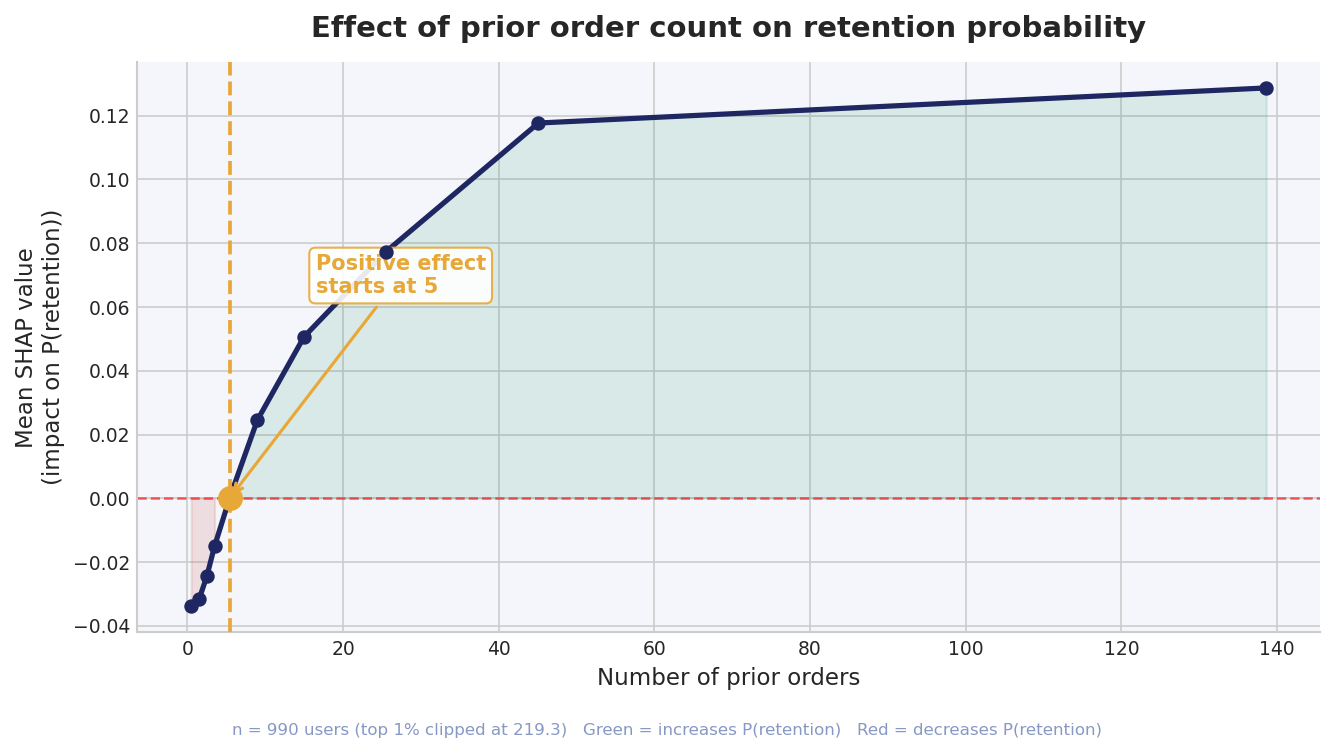

Saved: shap_pdp_market_order_cnt.png


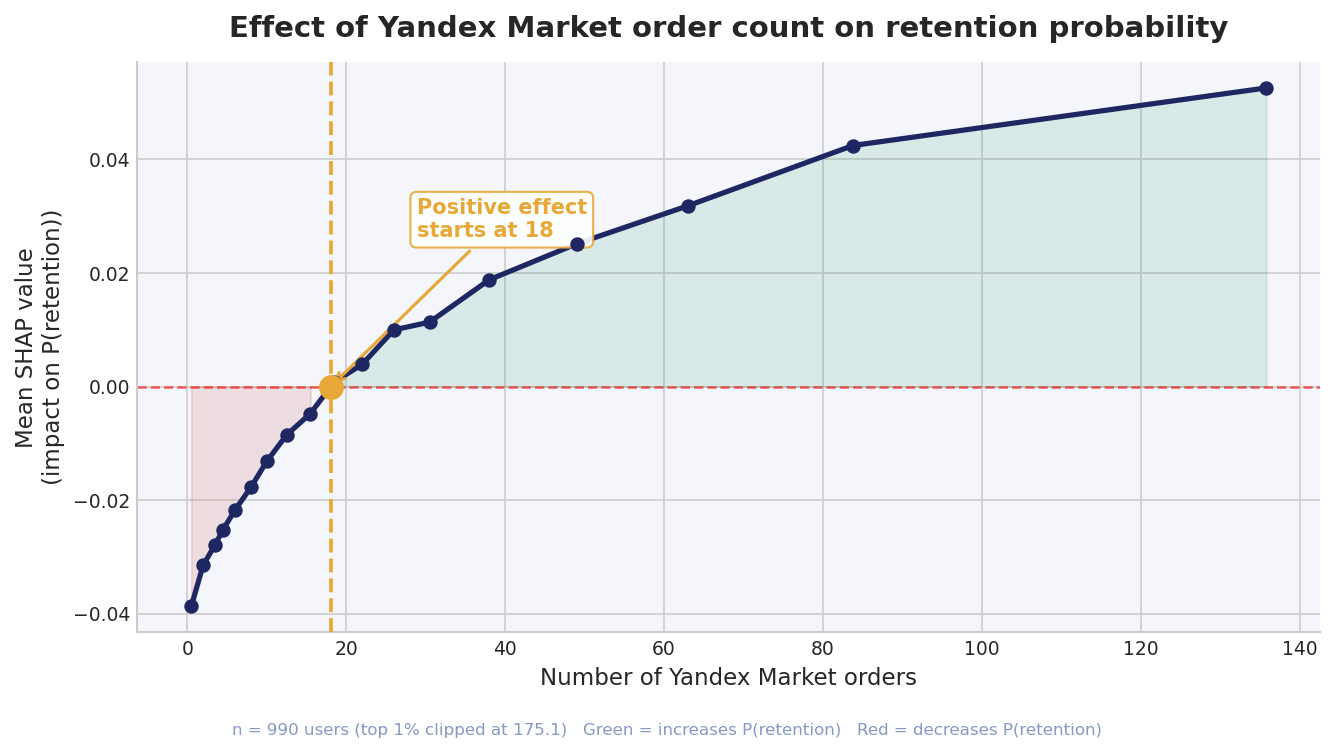

Saved: shap_pdp_offer_order_1m_conv.png


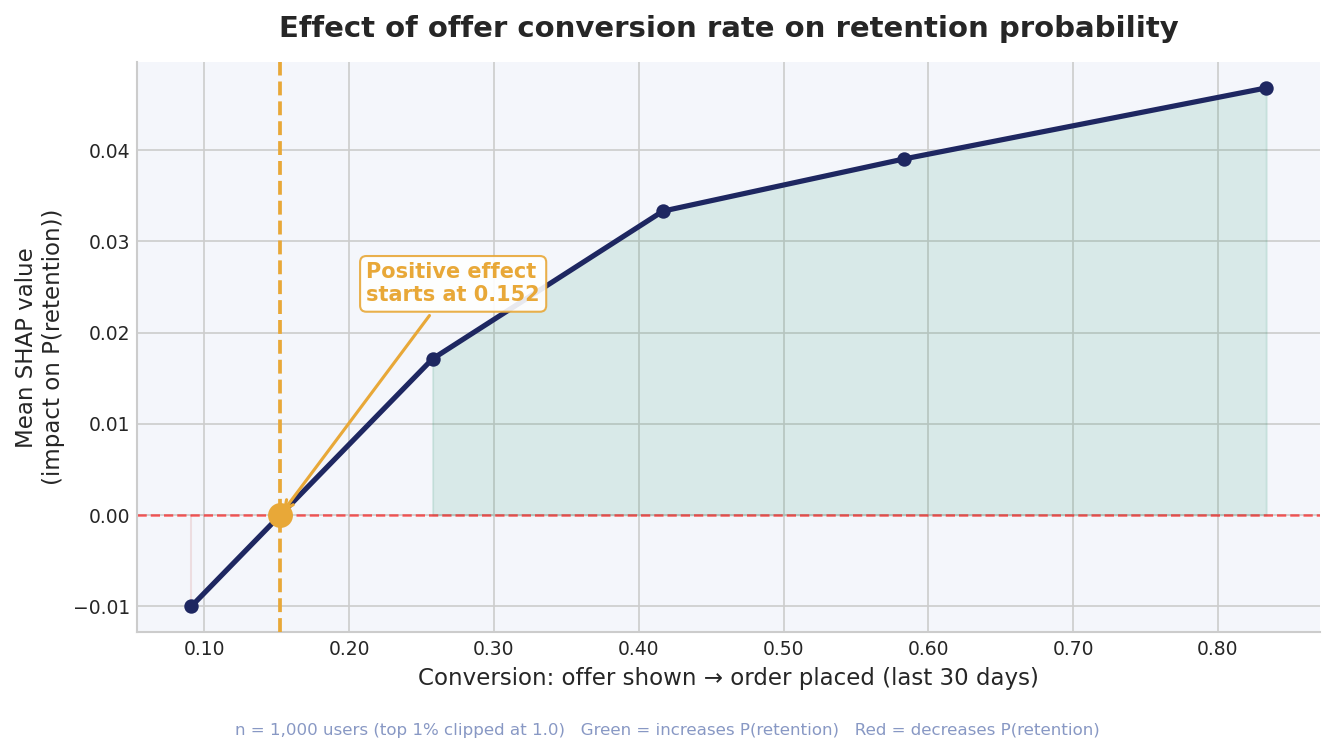

Saved: shap_pdp_order_estimated_ride_distance_km_1m_avg.png


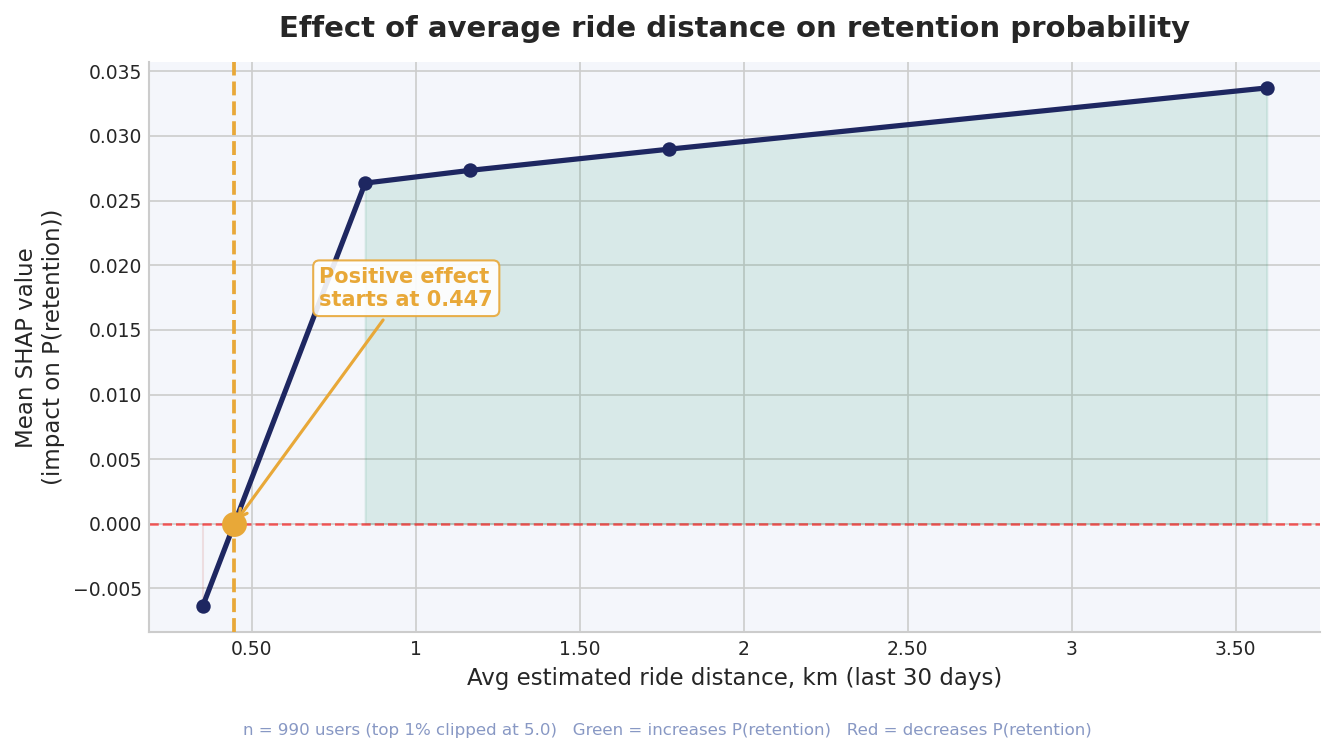


All SHAP plots saved.


In [37]:
FEATURES_CONFIG = [
    {
        'fname':    'orders_before_session_count',
        'xlabel':   'Number of prior orders',
        'title':    'Effect of prior order count on retention probability',
        'clip_pct': 99,
        'n_bins':   20,
    },
    {
        'fname':    'market_order_cnt',
        'xlabel':   'Number of Yandex Market orders',
        'title':    'Effect of Yandex Market order count on retention probability',
        'clip_pct': 99,
        'n_bins':   20,
    },
    {
        'fname':    'offer_order_1m_conv',
        'xlabel':   'Conversion: offer shown → order placed (last 30 days)',
        'title':    'Effect of offer conversion rate on retention probability',
        'clip_pct': 99,
        'n_bins':   20,
    },
    {
        'fname':    'order_estimated_ride_distance_km_1m_avg',
        'xlabel':   'Avg estimated ride distance, km (last 30 days)',
        'title':    'Effect of average ride distance on retention probability',
        'clip_pct': 99,
        'n_bins':   20,
    },
]


def _bin(x, sv, n_bins=20):
    pct     = np.percentile(x, np.linspace(0, 100, n_bins + 1))
    pct     = np.unique(pct)
    bin_ids = np.digitize(x, pct[1:-1])
    cx, ms  = [], []
    for b in range(len(pct) - 1):
        m = bin_ids == b
        if m.sum() < 5:
            continue
        cx.append((pct[b] + pct[b + 1]) / 2)
        ms.append(sv[m].mean())
    return np.array(cx), np.array(ms)


def _zero_crossing(cx, ms):
    """Linear interpolation of the negative-to-positive SHAP crossing point."""
    for i in range(1, len(ms)):
        if ms[i - 1] <= 0 and ms[i] > 0:
            x0, x1 = cx[i - 1], cx[i]
            y0, y1 = ms[i - 1], ms[i]
            return x0 - y0 * (x1 - x0) / (y1 - y0)
    return None


def plot_shap_pdp(cfg, shap_df, X_np, idx_exp, X_val, scaler_user):
    fname    = cfg['fname']
    xlabel   = cfg['xlabel']
    title    = cfg['title']
    clip_pct = cfg['clip_pct']
    n_bins   = cfg['n_bins']

    if fname not in shap_df.columns:
        print(f'SKIP {fname} — not found in shap_df')
        return

    feat_idx   = list(X_val.columns).index(fname)
    x_original = scaler_user.inverse_transform(X_np[idx_exp])[:, feat_idx]
    sv         = shap_df[fname].values

    p_clip  = np.percentile(x_original, clip_pct)
    mask    = x_original <= p_clip
    x_plot  = x_original[mask]
    sv_plot = sv[mask]

    cx, ms = _bin(x_plot, sv_plot, n_bins=n_bins)
    if len(cx) < 3:
        print(f'SKIP {fname} — too few bins')
        return

    threshold = _zero_crossing(cx, ms)
    fig, ax   = plt.subplots(figsize=(9, 5))
    fig.patch.set_facecolor('white')

    ax.axhline(0, color='red', linestyle='--', linewidth=1.2, alpha=0.6)
    ax.plot(cx, ms, color=BLUE, linewidth=2.5, zorder=3)
    ax.scatter(cx, ms, color=BLUE, s=35, zorder=4)
    ax.fill_between(cx, 0, ms, where=ms > 0, alpha=0.13, color=GREEN)
    ax.fill_between(cx, 0, ms, where=ms < 0, alpha=0.13, color=RED)

    if threshold is not None:
        ax.axvline(threshold, color=GOLD, linestyle='--', linewidth=1.8, zorder=5)
        ax.scatter([threshold], [0], color=GOLD, s=120, zorder=6, clip_on=False)
        x_range  = cx.max() - cx.min()
        ann_x    = (threshold + x_range * 0.08
                    if threshold < cx.min() + x_range * 0.6
                    else threshold - x_range * 0.35)
        ann_y    = ms.max() * 0.5 if ms.max() > 0 else ms.min() * 0.5
        thr_label = f'{threshold:.0f}' if threshold >= 1 else f'{threshold:.3f}'
        ax.annotate(
            f'Positive effect\nstarts at {thr_label}',
            xy=(threshold, 0), xytext=(ann_x, ann_y),
            fontsize=10, color=GOLD, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=GOLD, lw=1.5),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=GOLD, alpha=0.9),
        )
    else:
        direction = 'always positive' if ms.mean() > 0 else 'always negative'
        ax.text(0.97, 0.05, f'Effect is {direction}\nacross all values',
                transform=ax.transAxes, ha='right', va='bottom', fontsize=9, color=MUTED,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=MUTED, alpha=0.8))

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Mean SHAP value\n(impact on P(retention))', fontsize=11)
    ax.set_title(title, pad=12)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(
        lambda v, _: f'{v:,.2f}' if (abs(v) < 10 and v != int(v)) else f'{int(v):,}'
    ))
    ax.set_facecolor(LIGHT)

    n_shown = mask.sum()
    fig.text(
        0.5, 0.01,
        f'n = {n_shown:,} users (top {100 - clip_pct}% clipped at {p_clip:,.1f})   '
        'Green = increases P(retention)   Red = decreases P(retention)',
        ha='center', fontsize=8, color=MUTED,
    )
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    outfile = f'shap_pdp_{fname.replace("/", "_")}.png'
    fig.savefig(outfile, bbox_inches='tight', dpi=150)
    print(f'Saved: {outfile}')
    plt.show()
    plt.close(fig)


for cfg in FEATURES_CONFIG:
    plot_shap_pdp(cfg, shap_df, X_np, idx_exp, X_val, scaler_user)

print('\nAll SHAP plots saved.')
